# 🖼️ Introduction to OpenCV & Image Processing  

OpenCV is one of the most widely used libraries for **Computer Vision**.  
It allows us to read, process, analyze, and manipulate images and videos efficiently.  
In this notebook, we will explore the basics of **image handling** and some common transformations.  

---

## 📌 Key Concepts  

### 1. Reading Images  
- `cv2.imread(path)` loads an image from disk.  
- If the path is **incorrect**, OpenCV returns `None` (instead of an error).  
- Images are represented as **NumPy arrays** of shape `(Height, Width, Channels)`.  

---

### 2. Color Channels (BGR vs RGB)  
- OpenCV loads images in **BGR** format.  
- Matplotlib expects **RGB** format.  
- Fix this mismatch using `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`.  

---

### 3. Grayscale Conversion  
- Images can be converted to **Grayscale** (1 channel).  
- Stores pixel intensity values between **0–255**.  
- Useful for tasks like **edge detection** and **thresholding**.  

---

### 4. Image Visualization  
- `matplotlib.pyplot.imshow()` displays images.  
- By default, `matplotlib` assumes RGB, so BGR images will look wrong.  
- Different **colormaps** (`gray`, `magma`, `Accent`, etc.) can change the display style.  

---

### 5. Resizing Images  
- Use `cv2.resize()` to:  
  - Scale to **fixed dimensions** `(width, height)`.  
  - Scale proportionally using ratios `(fx, fy)`.  

---

### 6. Flipping Images  
- `cv2.flip(image, flipCode)` can flip images:  
  - `0` → Vertical flip  
  - `1` → Horizontal flip  
  - `-1` → Both vertical & horizontal  

---

### 7. Saving Images  
- Use `cv2.imwrite(filename, image)` to save processed images to disk.  

---



In [1]:
# 📌 Introduction to OpenCV & Image Processing (Code)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline  
import cv2

In [2]:
# ------------------------------
# 1. Reading Images
# ------------------------------
# If the image path is wrong, cv2.imread() will return None
img = cv2.imread("IMG_0213.jpg")
print("Type (invalid path):", type(img))  # NoneType if not found

Type (invalid path): <class 'numpy.ndarray'>


In [3]:
# Correct image path
img = cv2.imread("IMG_0213.jpg")
print("Type (valid image):", type(img))
print("Shape:", img.shape)

Type (valid image): <class 'numpy.ndarray'>
Shape: (685, 701, 3)


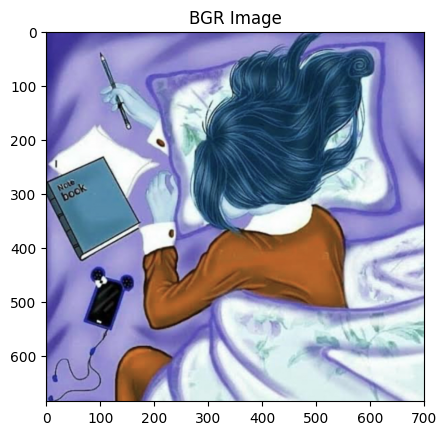

In [4]:
# Display with Matplotlib (will look wrong because of BGR format)
plt.imshow(img)
plt.title("BGR Image")
plt.show()

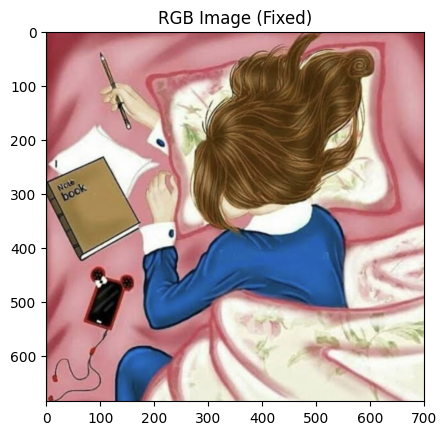

In [5]:
# ------------------------------
# 2. Converting BGR to RGB
# ------------------------------
fix_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(fix_img)
plt.title("RGB Image (Fixed)")
plt.show()

In [7]:
# ------------------------------
# 3. Converting to Grayscale
# ------------------------------
img_gray = cv2.imread("IMG_0213.jpg",
    cv2.IMREAD_GRAYSCALE
)
print("Gray Shape:", img_gray.shape)  # Now only 2D
print("Pixel Intensity Range:", img_gray.min(), "-", img_gray.max())

Gray Shape: (685, 701)
Pixel Intensity Range: 0 - 255


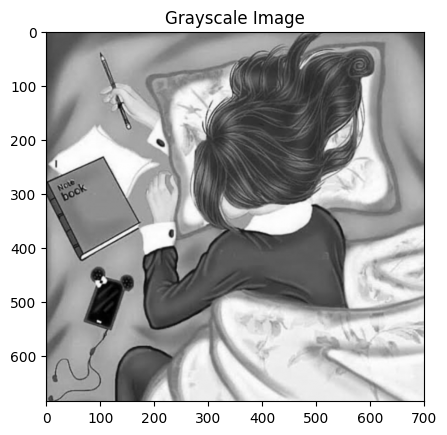

In [8]:
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Image")
plt.show()

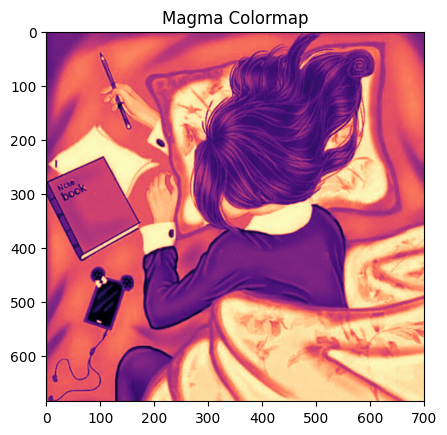

In [9]:
# Trying different colormaps
plt.imshow(img_gray, cmap='magma')
plt.title("Magma Colormap")
plt.show()

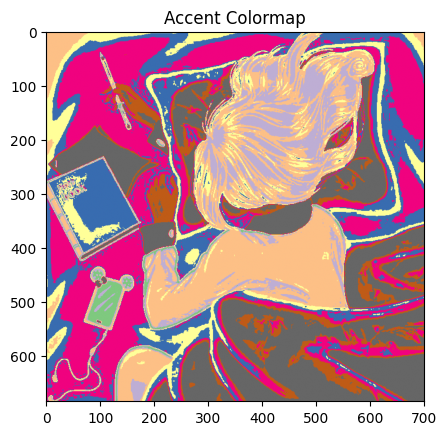

In [10]:
plt.imshow(img_gray, cmap='Accent')
plt.title("Accent Colormap")
plt.show()

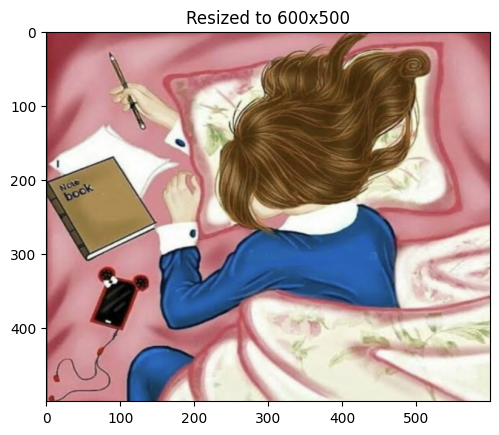

In [11]:
# ------------------------------
# 4. Resizing Images
# ------------------------------
# Resize with fixed width & height
fix_img_1 = cv2.resize(fix_img, (600, 500))  
plt.imshow(fix_img_1)
plt.title("Resized to 600x500")
plt.show()

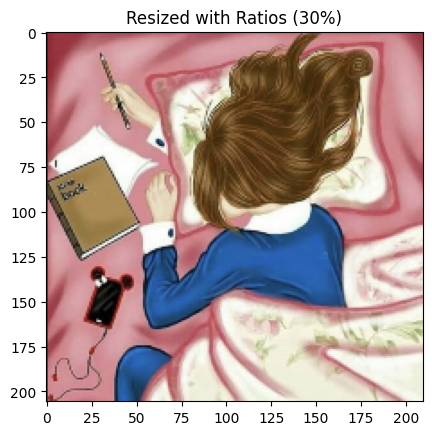

Resized Shape: (206, 210, 3)


In [12]:
# Resize using scale ratios
w_ratio, h_ratio = 0.3, 0.3
fix_img_2 = cv2.resize(fix_img, (0, 0), fx=w_ratio, fy=h_ratio)
plt.imshow(fix_img_2)
plt.title("Resized with Ratios (30%)")
plt.show()
print("Resized Shape:", fix_img_2.shape)

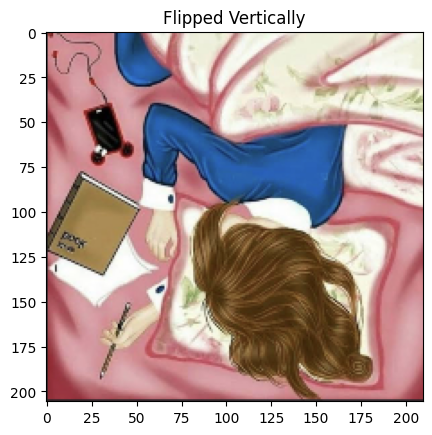

In [13]:
# ------------------------------
# 5. Flipping Images
# ------------------------------
img_flip = cv2.flip(fix_img_2, 0)  # Vertical flip
plt.imshow(img_flip)
plt.title("Flipped Vertically")
plt.show()

In [14]:
# ------------------------------
# 6. Saving Images
# ------------------------------
cv2.imwrite('new_generate_image.jpg', img_flip)
print("New image saved as 'new_generate_image.jpg'")

New image saved as 'new_generate_image.jpg'


# 🖼️ Opening Images with OpenCV (Without Matplotlib)

In OpenCV, images are handled as **NumPy arrays**. We can load, display, and close images easily using a few key functions.

---

## 📌 Important Functions

1. **`cv2.imread(path)`**  
   - Reads an image from the specified path.  
   - Returns a NumPy array if successful, or `None` if the path is invalid.  
   - Default loads in **BGR format** (not RGB).  

2. **`cv2.imshow(window_name, image)`**  
   - Opens a window and displays the given image.  
   - The first argument is the window title.  

3. **`cv2.waitKey(delay)`**  
   - Waits for a key press.  
   - `delay=0` → waits indefinitely until a key is pressed.  
   - `delay>0` → waits for that many milliseconds.  
   - Returns the ASCII value of the key pressed.  

4. **`cv2.destroyAllWindows()`**  
   - Closes all windows opened by OpenCV.  
   - Always call this after displaying images in a loop.  

---

## 💡 Example Workflow
1. Load the image with `cv2.imread()`.  
2. Show it using `cv2.imshow()`.  
3. Wait for a key press with `cv2.waitKey()`.  
4. Close the window with `cv2.destroyAllWindows()`.  

---


In [2]:
# 📌 Open an Image with OpenCV (without using Matplotlib)

import cv2

In [3]:
# ------------------------------
# 1. Read the Image
# ------------------------------
# cv2.imread() loads the image from the given path.
# It returns a NumPy array if successful, or None if the path is incorrect.
myimg = cv2.imread("IMG_0213.jpg")

In [ ]:
# ------------------------------
# 2. Display Image in a Window
# ------------------------------
# cv2.imshow() creates a window and shows the image.
cv2.imshow('My Window', myimg)

# cv2.waitKey() waits for a key press (in milliseconds).
# If we give no argument or 0, it waits indefinitely until a key is pressed.
cv2.waitKey()

27

: 

In [4]:
# ------------------------------
# 3. Using While Loop (Better Control)
# ------------------------------
# This loop will keep the window open until the ESC key (27) is pressed.
while True:
    cv2.imshow('My Window', myimg)
    
    # Check if ESC is pressed (ASCII 27)
    if cv2.waitKey(1) & 0xFF == 27:
        break

# ------------------------------
# 4. Close the Window
# ------------------------------
# Always destroy all windows after usage.
cv2.destroyAllWindows()

# ------------------------------
# 💡 Note:
# You can save this code as a .py file (e.g., test.py) and run it via Command Prompt:
# python test.py
# ------------------------------

# 🎥 Real-Time Video Capture with OpenCV

OpenCV provides an easy way to work with live video streams (e.g., from a webcam).  
We can capture frames, process them, and display them in real-time.

---

## 📌 Key Functions

1. **`cv2.VideoCapture(0)`**  
   - Opens the default camera (index 0).  
   - Use `1`, `2`, etc. if multiple cameras are connected.  

2. **`cap.read()`**  
   - Reads a single frame from the video stream.  
   - Returns `ret` (boolean) and `frame` (image).  

3. **`cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)`**  
   - Converts frames into grayscale (useful for preprocessing in vision tasks).  

4. **`cv2.imshow(window_name, frame)`**  
   - Displays each frame in a window.  

5. **`cv2.waitKey(1)`**  
   - Waits for 1 ms between frames.  
   - Can be combined with a key press (e.g., `ord('q')` to quit).  

6. **`cap.release()` & `cv2.destroyAllWindows()`**  
   - Release the webcam resource.  
   - Close all OpenCV windows.  

---

## 🎬 Example Variants
- **Grayscale stream:** Convert each frame to grayscale.  
- **Color stream:** Display frames directly in BGR (default OpenCV format).  

💡 You can press **Q** to quit the video stream.  


In [5]:
import cv2

# Open webcam (0 = default camera)
cap = cv2.VideoCapture(0)

# Get default video resolution
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
print(f"Camera Resolution: {width}x{height}")

# ---- Grayscale Stream ----
while True:
    ret, frame = cap.read()   # Capture frame
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    cv2.imshow('Grayscale Video', gray)             # Show grayscale video
    
    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()                # Release webcam
cv2.destroyAllWindows()      # Close all windows

Camera Resolution: 640.0x480.0


In [6]:
# ---- Normal Color Stream ----
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    cv2.imshow('Color Video', frame)  # Show color video (BGR format)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# ✍️ Air Writing with MediaPipe & OpenCV

This project allows you to **draw in the air using hand gestures** and track it in real-time using a webcam.  
We use **MediaPipe Hands** for hand landmark detection and OpenCV for visualization and drawing.

---

## 🔑 Key Concepts

1. **Hand Tracking (MediaPipe Hands)**  
   - Detects 21 hand landmarks (fingers + palm).  
   - We check finger states (up or down) to control drawing.  

2. **Finger Detection Logic**  
   - **Index + Middle Up → Selection Mode** (choose color / eraser).  
   - **Only Index Up → Drawing Mode** (draw on canvas).  
   - **Thumb** logic helps determine left/right orientation.  

3. **Drawing Mechanism**  
   - We maintain a transparent **canvas (`img_canvas`)** for all drawings.  
   - Combine it with the live feed using bitwise operations.  

4. **Toolbar (Color Picker)**  
   - Purple, Green, Red for brushes.  
   - Black as Eraser.  

5. **Save Option**  
   - Press **`s`** to save artwork as a `.png` file.  
   - Press **`ESC`** to quit.  

---

## 🎯 Features
- Real-time **gesture recognition** (index vs. middle finger up).  
- Virtual **color palette toolbar**.  
- Drawing & erasing directly in the air.  
- Save your artwork with a single key.  

📌 Applications:
- Educational tools  
- Interactive games  
- Creative art apps  
- Gesture-based interfaces  


In [10]:
import cv2
import numpy as np
import mediapipe as mp
import time

# Initialize MediaPipe Hands
mpHands = mp.solutions.hands
hands = mpHands.Hands(max_num_hands=1, min_detection_confidence=0.7)
mpDraw = mp.solutions.drawing_utils

# Default variables
draw_color = (255, 0, 255)   # Purple brush by default
brush_thickness = 7
eraser_thickness = 50
xp, yp = 0, 0   # Previous points for drawing
img_canvas = np.zeros((720, 1280, 3), np.uint8)  # Empty canvas

# Open webcam
cap = cv2.VideoCapture(0)
cap.set(3, 1280)  # Width
cap.set(4, 720)   # Height

# Finger tips IDs (based on MediaPipe hand landmarks)
tip_ids = [4, 8, 12, 16, 20]

# Function to detect which fingers are up
def fingers_up(hand_landmarks):
    fingers = []
    # Thumb (compare x coordinates)
    fingers.append(1 if hand_landmarks.landmark[tip_ids[0]].x < hand_landmarks.landmark[tip_ids[0]-1].x else 0)
    # Other 4 fingers (compare y coordinates)
    for id in range(1, 5):
        fingers.append(1 if hand_landmarks.landmark[tip_ids[id]].y < hand_landmarks.landmark[tip_ids[id]-2].y else 0)
    return fingers

while True:
    success, img = cap.read()
    img = cv2.flip(img, 1)   # Mirror the image
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    if results.multi_hand_landmarks:
        for handLms in results.multi_hand_landmarks:
            lm_list = []
            for id, lm in enumerate(handLms.landmark):
                h, w, c = img.shape
                lm_list.append((int(lm.x * w), int(lm.y * h)))

            if lm_list:
                x1, y1 = lm_list[8]   # Index tip
                x2, y2 = lm_list[12]  # Middle tip

                fingers = fingers_up(handLms)

                # Selection Mode (Index + Middle Up)
                if fingers[1] and fingers[2]:
                    xp, yp = 0, 0  # Reset drawing points
                    cv2.rectangle(img, (x1, y1-25), (x2, y2+25), draw_color, cv2.FILLED)

                    # Toolbar region
                    if y1 < 100:
                        if 250 < x1 < 450:
                            draw_color = (255, 0, 255)  # Purple
                        elif 550 < x1 < 750:
                            draw_color = (0, 255, 0)    # Green
                        elif 800 < x1 < 950:
                            draw_color = (0, 0, 255)    # Red
                        elif 1000 < x1 < 1200:
                            draw_color = (0, 0, 0)      # Eraser

                # Drawing Mode (Only Index Up)
                elif fingers[1] and not fingers[2]:
                    cv2.circle(img, (x1, y1), 15, draw_color, cv2.FILLED)
                    if xp == 0 and yp == 0:
                        xp, yp = x1, y1

                    if draw_color == (0, 0, 0):  # Eraser
                        cv2.line(img, (xp, yp), (x1, y1), draw_color, eraser_thickness)
                        cv2.line(img_canvas, (xp, yp), (x1, y1), draw_color, eraser_thickness)
                    else:  # Brush
                        cv2.line(img, (xp, yp), (x1, y1), draw_color, brush_thickness)
                        cv2.line(img_canvas, (xp, yp), (x1, y1), draw_color, brush_thickness)

                    xp, yp = x1, y1

            # Draw hand landmarks
            mpDraw.draw_landmarks(img, handLms, mpHands.HAND_CONNECTIONS)

    # Merge drawing canvas with webcam feed
    img_gray = cv2.cvtColor(img_canvas, cv2.COLOR_BGR2GRAY)
    _, img_inv = cv2.threshold(img_gray, 20, 255, cv2.THRESH_BINARY_INV)
    img_inv = cv2.cvtColor(img_inv, cv2.COLOR_GRAY2BGR)
    img = cv2.bitwise_and(img, img_inv)
    img = cv2.bitwise_or(img, img_canvas)

    # Toolbar (Top colors + eraser)
    cv2.rectangle(img, (250, 0), (450, 100), (255, 0, 255), cv2.FILLED)  # Purple
    cv2.rectangle(img, (550, 0), (750, 100), (0, 255, 0), cv2.FILLED)    # Green
    cv2.rectangle(img, (800, 0), (950, 100), (0, 0, 255), cv2.FILLED)    # Red
    cv2.rectangle(img, (1000, 0), (1200, 100), (0, 0, 0), cv2.FILLED)    # Eraser

    cv2.putText(img, "Save: Press 's'", (10, 700), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Show the output
    cv2.imshow("Air Writing", img)

    # Keyboard events
    key = cv2.waitKey(1)
    if key == ord('s'):
        timestamp = int(time.time())
        cv2.imwrite(f"air_drawing_{timestamp}.png", img_canvas)
        print("Artwork saved!")
    elif key == 27:  # ESC key
        break

cap.release()
cv2.destroyAllWindows()


In [11]:
# Try this 



import cv2
import numpy as np
import mediapipe as mp
import time

# Initialize MediaPipe Hands
mpHands = mp.solutions.hands
hands = mpHands.Hands(max_num_hands=1, min_detection_confidence=0.7)
mpDraw = mp.solutions.drawing_utils

# Default variables
draw_color = (255, 0, 255)   # Purple brush by default
brush_thickness = 7
eraser_thickness = 50
xp, yp = 0, 0   # Previous points for drawing
img_canvas = np.zeros((720, 1280, 3), np.uint8)  # Empty canvas

# Open webcam
cap = cv2.VideoCapture(0)
cap.set(3, 1280)  # Width
cap.set(4, 720)   # Height

# Finger tips IDs (based on MediaPipe hand landmarks)
tip_ids = [4, 8, 12, 16, 20]

# Function to detect which fingers are up
def fingers_up(hand_landmarks):
    fingers = []
    # Thumb (compare x coordinates)
    fingers.append(1 if hand_landmarks.landmark[tip_ids[0]].x < hand_landmarks.landmark[tip_ids[0]-1].x else 0)
    # Other 4 fingers (compare y coordinates)
    for id in range(1, 5):
        fingers.append(1 if hand_landmarks.landmark[tip_ids[id]].y < hand_landmarks.landmark[tip_ids[id]-2].y else 0)
    return fingers

while True:
    success, img = cap.read()
    img = cv2.flip(img, 1)   # Mirror the image
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    if results.multi_hand_landmarks:
        for handLms in results.multi_hand_landmarks:
            lm_list = []
            for id, lm in enumerate(handLms.landmark):
                h, w, c = img.shape
                lm_list.append((int(lm.x * w), int(lm.y * h)))

            if lm_list:
                x1, y1 = lm_list[8]   # Index tip
                x2, y2 = lm_list[12]  # Middle tip

                fingers = fingers_up(handLms)

                # 🎯 NEW FEATURE: Clear canvas if all 5 fingers are up
                if all(fingers):
                    img_canvas = np.zeros((720, 1280, 3), np.uint8)
                    cv2.putText(img, "Canvas Cleared!", (450, 400), cv2.FONT_HERSHEY_SIMPLEX,
                                2, (0, 0, 255), 3)

                # Selection Mode (Index + Middle Up)
                elif fingers[1] and fingers[2]:
                    xp, yp = 0, 0  # Reset drawing points
                    cv2.rectangle(img, (x1, y1-25), (x2, y2+25), draw_color, cv2.FILLED)

                    # Toolbar region
                    if y1 < 100:
                        if 250 < x1 < 450:
                            draw_color = (255, 0, 255)  # Purple
                        elif 550 < x1 < 750:
                            draw_color = (0, 255, 0)    # Green
                        elif 800 < x1 < 950:
                            draw_color = (0, 0, 255)    # Red
                        elif 1000 < x1 < 1200:
                            draw_color = (0, 0, 0)      # Eraser

                # Drawing Mode (Only Index Up)
                elif fingers[1] and not fingers[2]:
                    cv2.circle(img, (x1, y1), 15, draw_color, cv2.FILLED)
                    if xp == 0 and yp == 0:
                        xp, yp = x1, y1

                    if draw_color == (0, 0, 0):  # Eraser
                        cv2.line(img, (xp, yp), (x1, y1), draw_color, eraser_thickness)
                        cv2.line(img_canvas, (xp, yp), (x1, y1), draw_color, eraser_thickness)
                    else:  # Brush
                        cv2.line(img, (xp, yp), (x1, y1), draw_color, brush_thickness)
                        cv2.line(img_canvas, (xp, yp), (x1, y1), draw_color, brush_thickness)

                    xp, yp = x1, y1

            # Draw hand landmarks
            mpDraw.draw_landmarks(img, handLms, mpHands.HAND_CONNECTIONS)

    # Merge drawing canvas with webcam feed
    img_gray = cv2.cvtColor(img_canvas, cv2.COLOR_BGR2GRAY)
    _, img_inv = cv2.threshold(img_gray, 20, 255, cv2.THRESH_BINARY_INV)
    img_inv = cv2.cvtColor(img_inv, cv2.COLOR_GRAY2BGR)
    img = cv2.bitwise_and(img, img_inv)
    img = cv2.bitwise_or(img, img_canvas)

    # Toolbar (Top colors + eraser)
    cv2.rectangle(img, (250, 0), (450, 100), (255, 0, 255), cv2.FILLED)  # Purple
    cv2.rectangle(img, (550, 0), (750, 100), (0, 255, 0), cv2.FILLED)    # Green
    cv2.rectangle(img, (800, 0), (950, 100), (0, 0, 255), cv2.FILLED)    # Red
    cv2.rectangle(img, (1000, 0), (1200, 100), (0, 0, 0), cv2.FILLED)    # Eraser

    cv2.putText(img, "Save: Press 's' | Clear: 5 Fingers", (10, 700),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Show the output
    cv2.imshow("Air Writing", img)

    # Keyboard events
    key = cv2.waitKey(1)
    if key == ord('s'):
        timestamp = int(time.time())
        cv2.imwrite(f"air_drawing_{timestamp}.png", img_canvas)
        print("Artwork saved!")
    elif key == 27:  # ESC key
        break

cap.release()
cv2.destroyAllWindows()


# 🖌️ Virtual Painter using MediaPipe & OpenCV

This project demonstrates a **Virtual Painter (Air Drawing App)** built using:
- **OpenCV** for webcam capture and image processing
- **MediaPipe Hands** for hand landmark detection
- **NumPy** for array operations

---

## 🔑 Key Concepts
1. **Hand Tracking with MediaPipe**
   - Detects 21 landmarks on the hand (fingertips, joints, etc.)
   - Allows gesture-based interaction without physical input devices.

2. **Drawing Logic**
   - **Index Finger Up** → Drawing mode  
   - **All Fingers Up** → Clear the canvas  
   - When index finger is lifted, previous drawing coordinates are reset.

3. **Canvas & Overlay**
   - A transparent canvas is created (`np.zeros_like(frame)`) to store drawings.
   - Bitwise operations (`cv2.bitwise_and`, `cv2.bitwise_or`) are used to overlay drawings on the live webcam feed.

---

## 🎯 Applications
- Touchless **digital whiteboards**
- Interactive **AR/VR applications**
- Educational tools for **gesture-based learning**
- Fun **drawing games** with hand gestures


In [12]:
import cv2
import numpy as np
import mediapipe as mp

# Initialize MediaPipe Hand Detector
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1)   # Detect only 1 hand
mp_draw = mp.solutions.drawing_utils      # For drawing landmarks

# Start webcam
cap = cv2.VideoCapture(0)
canvas = None  # Empty canvas for drawing

# Drawing settings
draw_color = (255, 0, 255)  # Purple color
brush_thickness = 8         # Thickness of brush

# Previous finger coordinates
xp, yp = 0, 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)  # Mirror effect
    h, w, c = frame.shape

    # Initialize canvas once
    if canvas is None:
        canvas = np.zeros_like(frame)

    # Convert frame to RGB for MediaPipe
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)

    if result.multi_hand_landmarks:
        for handLms in result.multi_hand_landmarks:
            lm_list = []
            # Store all landmark positions
            for id, lm in enumerate(handLms.landmark):
                cx, cy = int(lm.x * w), int(lm.y * h)
                lm_list.append((cx, cy))

            if lm_list:
                x1, y1 = lm_list[8]   # Index finger tip
                x2, y2 = lm_list[12]  # Middle finger tip

                # Detect which fingers are up
                fingers = []
                for tip_id in [8, 12, 16, 20]:
                    fingers.append(lm_list[tip_id][1] < lm_list[tip_id - 2][1])

                # Drawing mode → Only index finger up
                if fingers[0] and not fingers[1]:
                    cv2.circle(frame, (x1, y1), 8, draw_color, -1)  # Visualize fingertip
                    if xp == 0 and yp == 0:
                        xp, yp = x1, y1
                    # Draw line from previous point to current point
                    cv2.line(canvas, (xp, yp), (x1, y1), draw_color, brush_thickness)
                    xp, yp = x1, y1
                else:
                    xp, yp = 0, 0  # Reset if finger lifted

                # Clear canvas if all fingers are up
                if all(fingers):
                    canvas = np.zeros_like(frame)

            # Draw landmarks on the hand
            mp_draw.draw_landmarks(frame, handLms, mp_hands.HAND_CONNECTIONS)

    # Merge canvas and frame
    gray_canvas = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray_canvas, 20, 255, cv2.THRESH_BINARY)
    inv_mask = cv2.bitwise_not(mask)
    frame_bg = cv2.bitwise_and(frame, frame, mask=inv_mask)
    frame_fg = cv2.bitwise_and(canvas, canvas, mask=mask)
    final = cv2.add(frame_bg, frame_fg)

    # Show final output
    cv2.imshow("Virtual Painter", final)

    # Exit on pressing 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


# ✋ Virtual Painter with Pinch Gesture (MediaPipe + OpenCV)

This project implements a **gesture-based drawing app** using:
- **OpenCV** for real-time video capture & overlay
- **MediaPipe Hands** for detecting hand landmarks
- **NumPy** for canvas operations
- **Math (Euclidean distance)** for detecting pinch gestures

---

## 🔑 How It Works
1. **Hand Detection**  
   - MediaPipe detects hand landmarks (21 key points).
   - We use **Index Finger Tip** and **Thumb Tip** for gesture recognition.

2. **Pinch Detection**  
   - Calculate **Euclidean distance** between index fingertip and thumb tip.  
   - If the distance < threshold (40px), it means a **pinch gesture**.  
   - While pinched, draw a line on the canvas following the finger.

3. **Drawing Logic**  
   - **Pinch = Draw mode**  
   - **Release = Stop drawing**  
   - Lines are drawn continuously between consecutive finger positions.

4. **Overlay**  
   - The canvas (drawings) is blended with the live camera feed using `cv2.addWeighted()`.

---

## 🎯 Applications
- **Gesture-based drawing boards**
- **Touchless whiteboard controls**
- **Creative AR/VR applications**
- **Gamified learning tools**


In [13]:
import cv2
import mediapipe as mp
import numpy as np
import math

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1)       # Track only 1 hand
mp_draw = mp.solutions.drawing_utils          # Draw hand landmarks

# Create a blank canvas for drawing
canvas = np.zeros((480, 640, 3), dtype=np.uint8)

# Variables to track drawing state
drawing = False
prev_x, prev_y = 0, 0   # Previous fingertip position

# Function to calculate Euclidean distance
def euclidean_distance(pt1, pt2):
    return math.sqrt((pt1[0] - pt2[0]) ** 2 + (pt1[1] - pt2[1]) ** 2)

# Start webcam
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    frame = cv2.flip(frame, 1)  # Mirror effect
    h, w, c = frame.shape

    # Convert to RGB for MediaPipe
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb_frame)

    if result.multi_hand_landmarks:
        for hand_landmarks in result.multi_hand_landmarks:
            # Get coordinates of index fingertip and thumb tip
            index_finger = hand_landmarks.landmark[mp_hands.HandLandmark.INDEX_FINGER_TIP]
            thumb_tip = hand_landmarks.landmark[mp_hands.HandLandmark.THUMB_TIP]

            ix, iy = int(index_finger.x * w), int(index_finger.y * h)
            tx, ty = int(thumb_tip.x * w), int(thumb_tip.y * h)

            # Compute distance between thumb and index finger
            distance = euclidean_distance((ix, iy), (tx, ty))

            # If distance small → Pinch detected → Draw mode
            if distance < 40:
                drawing = True
                if prev_x == 0 and prev_y == 0:
                    prev_x, prev_y = ix, iy  # Starting point
                # Draw line on canvas following fingertip
                cv2.line(canvas, (prev_x, prev_y), (ix, iy), (255, 0, 0), 5)
                prev_x, prev_y = ix, iy
            else:
                drawing = False
                prev_x, prev_y = 0, 0  # Reset when not pinching

            # Draw landmarks on the frame for visualization
            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

    # Blend canvas with webcam feed
    frame = cv2.addWeighted(frame, 0.5, canvas, 0.5, 0)

    # Display instructions
    cv2.putText(frame, 'Pinch (Thumb + Index) to Draw', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Show output
    cv2.imshow("Virtual Painter", frame)

    # Quit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


# ✋ Drawing with Hand Gestures (MediaPipe + OpenCV + Pygame)

This project combines **OpenCV**, **MediaPipe**, and **Pygame** to create a virtual drawing application where:
- Your **hand movement** (detected via webcam) controls the brush.
- The drawing appears in a **Pygame canvas**.
- OpenCV displays the live webcam feed with detected hand landmarks.

---

## 🔑 Key Concepts
1. **MediaPipe Hands**  
   - Detects **21 hand landmarks** in real-time.
   - Used here to track the **wrist position** as the brush cursor.

2. **Coordinate Mapping**  
   - Normalized MediaPipe hand coordinates (0–1) are converted to Pygame screen coordinates.

3. **Drawing Logic**  
   - If a hand is detected, draw a **line** from the last known wrist position to the current position.
   - This creates a continuous stroke effect.

4. **Dual Display**  
   - **OpenCV Window** → Shows live camera feed with hand landmarks.  
   - **Pygame Window** → Acts as the white canvas where drawing happens.  

---

## 🎯 Applications
- **Touchless whiteboards**  
- **AR/VR-based sketching**  
- **Creative gesture-based interfaces**  
- **Assistive technology for hands-free drawing**


In [14]:
import cv2
import mediapipe as mp
import pygame

# ----------------------------
# 🎮 Initialize Pygame
# ----------------------------
pygame.init()

# Screen dimensions
WIDTH, HEIGHT = 640, 480
FPS = 60
BRUSH_SIZE = 10

# Setup Pygame drawing canvas
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Draw with Your Hand!")

# Colors
WHITE = (255, 255, 255)
BRUSH_COLOR = (0, 255, 0)  # Green Brush

# ----------------------------
# ✋ Initialize MediaPipe Hands
# ----------------------------
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(min_detection_confidence=0.7,
                       min_tracking_confidence=0.5)
mp_draw = mp.solutions.drawing_utils

# ----------------------------
# 📌 Hand Detection Function
# ----------------------------
def detect_hand_gesture(frame):
    """Detect hand landmarks in a frame using MediaPipe."""
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)

    hand_landmarks = None
    if results.multi_hand_landmarks:
        for hand in results.multi_hand_landmarks:
            mp_draw.draw_landmarks(frame, hand, mp_hands.HAND_CONNECTIONS)
            hand_landmarks = hand  # Track the latest detected hand

    return hand_landmarks

# ----------------------------
# 📌 Convert Hand to Screen Coordinates
# ----------------------------
def hand_to_screen_coordinates(hand_landmarks, frame_width, frame_height):
    """Convert hand (wrist) position to screen coordinates."""
    wrist_x = int(hand_landmarks.landmark[mp_hands.HandLandmark.WRIST].x * frame_width)
    wrist_y = int(hand_landmarks.landmark[mp_hands.HandLandmark.WRIST].y * frame_height)
    return wrist_x, wrist_y

# ----------------------------
# 🚀 Main Application Loop
# ----------------------------
def main():
    screen.fill(WHITE)  # Start with a white background

    cap = cv2.VideoCapture(0)  # Start webcam
    clock = pygame.time.Clock()

    last_position = None  # Track last brush position

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Mirror effect for natural movement
        frame = cv2.flip(frame, 1)

        # Detect hand landmarks
        hand_landmarks = detect_hand_gesture(frame)

        # If hand detected → draw on canvas
        if hand_landmarks:
            wrist_x, wrist_y = hand_to_screen_coordinates(hand_landmarks, WIDTH, HEIGHT)

            # Draw continuous line from last to current wrist position
            if last_position:
                pygame.draw.line(screen, BRUSH_COLOR, last_position, (wrist_x, wrist_y), BRUSH_SIZE)

            last_position = (wrist_x, wrist_y)
        else:
            last_position = None  # Reset when no hand detected

        # Show webcam feed with landmarks (OpenCV window)
        cv2.imshow("Hand Tracking Feed", frame)

        # Update Pygame canvas
        pygame.display.update()

        # Handle Pygame events
        for event in pygame.event.get():
            if event.type == pygame.QUIT:  # Exit button
                cap.release()
                pygame.quit()
                cv2.destroyAllWindows()
                return
            elif event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE:  # ESC key
                cap.release()
                pygame.quit()
                cv2.destroyAllWindows()
                return

        clock.tick(FPS)  # Maintain frame rate

# ----------------------------
# 🏁 Run App
# ----------------------------
if __name__ == "__main__":
    main()


pygame 2.6.1 (SDL 2.28.4, Python 3.11.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


# ✋ Virtual Drawing with Hand Gestures (MediaPipe + OpenCV + Pygame)

This project demonstrates how to **draw on top of a live camera feed** using your hand as a virtual brush.  
It combines **three key libraries**:

- **OpenCV** → Captures webcam video feed  
- **MediaPipe Hands** → Detects hand landmarks in real-time  
- **Pygame** → Provides a drawing canvas and renders both the camera feed + brush strokes  

---

## 🔑 How It Works
1. **Hand Tracking**  
   - MediaPipe detects **21 hand landmarks**.  
   - We specifically track the **wrist landmark** as the brush position.

2. **Drawing Logic**  
   - A continuous line is drawn from the **previous wrist position** to the **current wrist position**.  
   - This simulates a brush stroke.

3. **Overlay**  
   - The webcam feed is displayed as the **background** in the Pygame window.  
   - Drawing strokes are layered **on top** of the video.

---

## 🎯 Features
- Real-time **hand-controlled drawing**.  
- Brush follows wrist movement.  
- Webcam feed acts as a live background.  
- Press **ESC** or close the window to exit.  

---

## 💡 Applications
- **Virtual whiteboards**  
- **Gesture-based interaction systems**  
- **AR drawing apps**  
- **Educational tools for computer vision**


In [15]:
import cv2
import mediapipe as mp
import pygame
import numpy as np

# ----------------------------
# 🎮 Initialize Pygame
# ----------------------------
pygame.init()
WIDTH, HEIGHT = 640, 480
FPS = 60
BRUSH_SIZE = 10

# Setup game window
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Draw with Your Hand!")

# Colors
WHITE = (255, 255, 255)
BRUSH_COLOR = (0, 255, 0)  # Green

# ----------------------------
# ✋ Initialize MediaPipe Hands
# ----------------------------
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(min_detection_confidence=0.7,
                       min_tracking_confidence=0.5)
mp_draw = mp.solutions.drawing_utils

# ----------------------------
# 📌 Detect Hand Landmarks
# ----------------------------
def detect_hand_gesture(frame):
    """Process frame with MediaPipe and return hand landmarks."""
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)

    hand_landmarks = None
    if results.multi_hand_landmarks:
        for hand in results.multi_hand_landmarks:
            # Draw landmarks on OpenCV feed
            mp_draw.draw_landmarks(frame, hand, mp_hands.HAND_CONNECTIONS)
            hand_landmarks = hand
    return hand_landmarks

# ----------------------------
# 📌 Convert Hand to Screen Coordinates
# ----------------------------
def hand_to_screen_coordinates(hand_landmarks, frame_width, frame_height):
    """Convert wrist landmark into Pygame screen coordinates."""
    wrist_x = int(hand_landmarks.landmark[mp_hands.HandLandmark.WRIST].x * frame_width)
    wrist_y = int(hand_landmarks.landmark[mp_hands.HandLandmark.WRIST].y * frame_height)
    return wrist_x, wrist_y

# ----------------------------
# 🚀 Main Application
# ----------------------------
def main():
    cap = cv2.VideoCapture(0)  # Open webcam
    clock = pygame.time.Clock()
    last_position = None  # Store last wrist position for continuous drawing

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Mirror effect for natural interaction
        frame = cv2.flip(frame, 1)

        # Detect hand
        hand_landmarks = detect_hand_gesture(frame)

        if hand_landmarks:
            # Map hand position to screen coords
            wrist_x, wrist_y = hand_to_screen_coordinates(hand_landmarks, WIDTH, HEIGHT)

            # Draw a line from last wrist pos → current wrist pos
            if last_position:
                pygame.draw.line(screen, BRUSH_COLOR, last_position, (wrist_x, wrist_y), BRUSH_SIZE)

            last_position = (wrist_x, wrist_y)
        else:
            last_position = None  # Reset if no hand detected

        # Convert OpenCV frame → Pygame surface
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_surface = pygame.surfarray.make_surface(np.rot90(frame_rgb))  # Rotate for correct orientation

        # Display webcam feed as background
        screen.blit(frame_surface, (0, 0))

        # Update window
        pygame.display.update()

        # Handle events (Quit / ESC)
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                cap.release()
                pygame.quit()
                cv2.destroyAllWindows()
                return
            elif event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE:
                cap.release()
                pygame.quit()
                cv2.destroyAllWindows()
                return

        clock.tick(FPS)

# Run app
if __name__ == "__main__":
    main()


# 🎨 Draw on Face with Finger (OpenCV + MediaPipe + Pygame)

This project allows you to **draw on top of your detected face using your finger**.  
It merges **Face Detection** with **Hand Gesture Tracking**:

- **OpenCV** → Face detection with Haar Cascade  
- **MediaPipe Hands** → Tracks hand landmarks  
- **Pygame** → Drawing canvas layered on top of webcam feed  

---

## 🔑 Workflow
1. **Face Detection**  
   - Haar Cascade detects the face.  
   - A **black mask** is applied over the detected face region.  

2. **Hand Tracking**  
   - MediaPipe detects **index finger tip**.  
   - Finger tip coordinates are converted to **screen space**.  

3. **Drawing**  
   - A continuous line is drawn between the **previous finger position** and the **current position**.  
   - This simulates finger painting directly on the face.  

4. **Overlay**  
   - The face mask + drawing strokes are blended with the camera feed.  
   - Final result is displayed in a **pygame window**.  

---

## 🎯 Features
- Real-time **face detection + masking**  
- Finger-controlled **virtual brush**  
- Drawing restricted to the detected face region  
- Press **ESC** or close window to exit  

---

## 💡 Applications
- **AR face filters** (fun apps like Snapchat/Instagram filters)  
- **Gesture-based drawing games**  
- **Educational tools** for CV-based AR interactions  
- **Interactive art projects**


In [ ]:
import cv2
import mediapipe as mp
import pygame
import numpy as np

# ----------------------------
# 🎮 Initialize Pygame
# ----------------------------
pygame.init()
WIDTH, HEIGHT = 640, 480
FPS = 60
BRUSH_SIZE = 10
MASK_COLOR = (0, 0, 0)  # Black overlay for face

screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Draw on Face with Finger!")

# Colors
WHITE = (255, 255, 255)
BRUSH_COLOR = (0, 255, 0)  # Green Brush

# ----------------------------
# ✋ MediaPipe Hands
# ----------------------------
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(min_detection_confidence=0.7,
                       min_tracking_confidence=0.5)
mp_draw = mp.solutions.drawing_utils

# ----------------------------
# 😀 OpenCV Face Detection
# ----------------------------
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
                                     'haarcascade_frontalface_default.xml')

# ----------------------------
# 📌 Detect Hand Landmarks
# ----------------------------
def detect_hand_gesture(frame):
    """Detect and return hand landmarks from frame."""
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)

    hand_landmarks = None
    if results.multi_hand_landmarks:
        for hand in results.multi_hand_landmarks:
            mp_draw.draw_landmarks(frame, hand, mp_hands.HAND_CONNECTIONS)
            hand_landmarks = hand
    return hand_landmarks

# ----------------------------
# 📌 Convert Finger Tip to Screen Coordinates
# ----------------------------
def hand_to_screen_coordinates(hand_landmarks, frame_width, frame_height):
    """Return index finger tip coordinates in screen space."""
    index_finger_tip = hand_landmarks.landmark[mp_hands.HandLandmark.INDEX_FINGER_TIP]
    x = int(index_finger_tip.x * frame_width)
    y = int(index_finger_tip.y * frame_height)
    return x, y

# ----------------------------
# 📌 Detect Face using Haar Cascade
# ----------------------------
def detect_face(frame):
    """Detect faces and return bounding box + ROI."""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        face_roi = frame[y:y+h, x:x+w]
        return (x, y, w, h), face_roi
    return None, None

# ----------------------------
# 🚀 Main Loop
# ----------------------------
def main():
    cap = cv2.VideoCapture(0)
    clock = pygame.time.Clock()

    last_position = None
    mask_image = None  # Stores the mask overlay

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Mirror effect
        frame = cv2.flip(frame, 1)

        # Detect face and apply mask
        face_coords, face_roi = detect_face(frame)
        if face_coords:
            x, y, w, h = face_coords
            if mask_image is None:
                mask_image = np.zeros_like(frame)
            mask_image[y:y+h, x:x+w] = MASK_COLOR  # Black mask overlay

        # Detect hand
        hand_landmarks = detect_hand_gesture(frame)
        if hand_landmarks:
            x, y = hand_to_screen_coordinates(hand_landmarks, WIDTH, HEIGHT)

            # Draw line following finger tip
            if last_position:
                pygame.draw.line(screen, BRUSH_COLOR, last_position, (x, y), BRUSH_SIZE)
            last_position = (x, y)
        else:
            last_position = None  # Reset if no hand detected

        # Blend face mask with webcam feed
        if mask_image is not None:
            frame = cv2.addWeighted(frame, 1, mask_image, 0.5, 0)

        # Convert frame to pygame surface
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_surface = pygame.surfarray.make_surface(np.rot90(frame_rgb))

        # Display webcam background + drawings
        screen.blit(frame_surface, (0, 0))
        pygame.display.update()

        # Handle exit events
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                cap.release()
                pygame.quit()
                cv2.destroyAllWindows()
                return
            elif event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE:
                cap.release()
                pygame.quit()
                cv2.destroyAllWindows()
                return

        clock.tick(FPS)

if __name__ == "__main__":
    main()